# Convolutional Neural Networks

## Preliminaries

In this practical session you will implement and train several Convolutional Neural Networks (CNNs) using the Keras framework with a Tensorflow backend. If you are not already familiar with Keras, you can go over the [following tutorial](https://github.com/tueimage/essential-skills/blob/master/keras.md). More detailed information on the different functionalities can be found in the [Keras library documentation](https://keras.io/). 

Note that for this set of exercise CPU-only Tensorflow, which you should already have installed, is sufficient (i.e. GPU-support is not required but it will make your experiments run faster). 

You are also required to use the `gryds` package for data augmentation that you can install directly from git: `pip install git+https://github.com/tueimage/gryds/`.

You also have to install the Keras deep learning framework (if you have not done so already) by running `conda install keras`. Note that there are two implementations of Keras, one from https://keras.io/ and another one that ships with Tensorflow. Here we use the former. 

## MNIST
We will first train a simple CNN to classify handwritten digits using the MNIST dataset. This dataset is often referred to as the "Hello world!" example of deep learning because it can be used to quickly illustrate a small neural network in action (and obtain a decent classification accuracy in the process). More information on it can be found [here](http://yann.lecun.com/exdb/mnist/).

First, let's load the dataset and visualize some images.

Using TensorFlow backend.


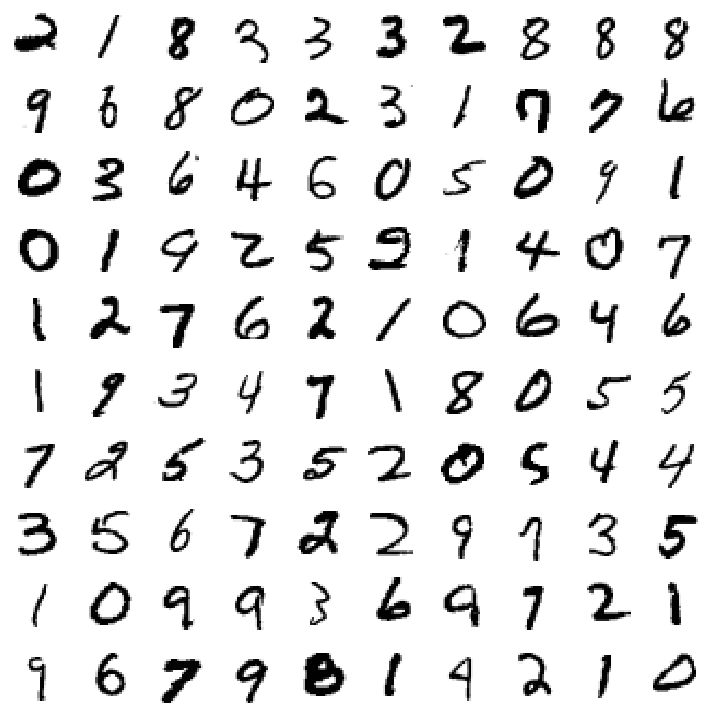

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils import to_categorical

# load the MNIST the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# scale the image intensities to the 0-1 range
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)

# convert the data to channel-last
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# convert the labels to one-hot encoded
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

def plot_images(images, dim=(10, 10), figsize=(10, 10), title=''):
    
    plt.figure(figsize=figsize)
    
    for i in range(images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    
plot_images(x_train[np.random.randint(0, x_train.shape[0], size=100)].reshape(100, 28, 28))

The MNIST classification task is quite simple: given an image, predict the digit that it contains. Thus, this is a 10-class classification problem.

Let's define a simple network for the handwritten digit classification.

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               1179776   
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)              

Compile and train the network (note that this could take a while).

In [3]:
from keras.losses import categorical_crossentropy
from keras.optimizers import Adam

model.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=128,
          epochs=12,
          verbose=1,
          validation_data=(x_test, y_test))

score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 101s 2ms/step - loss: 0.2434 - accuracy: 0.9264 - val_loss: 0.0509 - val_accuracy: 0.9828
Epoch 2/12
60000/60000 [==============================] - 105s 2ms/step - loss: 0.0845 - accuracy: 0.9744 - val_loss: 0.0383 - val_accuracy: 0.9870
Epoch 3/12
60000/60000 [==============================] - 106s 2ms/step - loss: 0.0634 - accuracy: 0.9803 - val_loss: 0.0319 - val_accuracy: 0.9896
Epoch 4/12
60000/60000 [==============================] - 105s 2ms/step - loss: 0.0537 - accuracy: 0.9837 - val_loss: 0.0290 - val_accuracy: 0.9895
Epoch 5/12
60000/60000 [==============================] - 99s 2ms/step - loss: 0.0449 - accuracy: 0.9862 - val_loss: 0.0296 - val_accuracy: 0.9902
Epoch 6/12
60000/60000 [==============================] - 98s 2ms/step - loss: 0.0383 - accuracy: 0.9879 - val_loss: 0.0288 - val_accuracy: 0.9900
Epoch 7/12
60000/60000 [==============================] - 99s 2m

Now that the model is trained, we can evaluate its performance on the independent test dataset.

In [13]:
score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.028865184726537745
Test accuracy: 0.9914000034332275


## U-Net
The U-Net convolutional neural network architecture was first developed for biomedical image segmentation and is to this day one of the most widely used methods for image segmentation. The details of the architecture can be found in the [original paper](https://arxiv.org/abs/1505.04597). In this practical we will build and train a U-Net network that is able to segment blood vessels in retinal images. 

### Loading and visualizing the data
The data for this task is taken from the [DRIVE](https://www.kaggle.com/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction) database. It consists of photographs of the retina, where the goal is to segment the blood vessels within. The dataset has a total of 40 photographs, divided in 20 images for training and 20 for testing. The images corresponding to the DRIVE test set can be found [here](https://drive.google.com/file/d/1Enau6gb_BtPKCg1Yt5MZIIM18pfVEhxQ/view?usp=sharing).

Let's load the training set and visualize an image with the corresponding blood vessel segmentation. For training we will divide the data in a training and a validation set to monitor the model during training.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from glob import glob
from unet_utils import load_data

# location of the DRIVE dataset
data_folder = r'C:\Users\20192447\Documents\Master\Q1 2025\Machine learning\8dm50-machine-learning-master\DRIVE'
train_paths = glob(data_folder + 'training/images/*.tif')
images, masks, segmentations = load_data(train_paths)

# print the shape of image dataset
print(images.shape)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(images[0])

plt.subplot(1, 2, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(segmentations[0][:, :, 0])

plt.show()

# divide in training and validation
train_images, val_images, train_masks, val_masks, train_segmentations, val_segmentations = train_test_split(
    images, masks, segmentations, test_size=0.2, random_state=7)

# print the shape of the training and valudation datasets
print(train_images.shape)
print(train_masks.shape)
print(train_segmentations.shape)
print(val_images.shape)
print(val_masks.shape)
print(val_segmentations.shape)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\Users\20192447\Anaconda3\envs\8dm50\lib\site-packages\IPython\core\interactiveshell.py", line 3343, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-5-d9cb5d404522>", line 6, in <module>
    from unet_utils import load_data
ModuleNotFoundError: No module named 'unet_utils'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\20192447\Anaconda3\envs\8dm50\lib\site-packages\IPython\core\interactiveshell.py", line 2044, in showtraceback
    stb = value._render_traceback_()
AttributeError: 'ModuleNotFoundError' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\20192447\Anaconda3\envs\8dm50\lib\site-packages\IPython\core\ultratb.py", line 1169, in get_records
    return _fixed_getinnerframes(etb, number_of_lines_of_context,

### Training a U-Net model

You are already provided with implementation of the U-Net architecture in `unet_model.py`. This is a modular implementation and can be used to generate U-Net architectures with a variety of hyperparameters such as depth and number of feature maps. Before using the model, examine the code and documentation and make sure that you understand all the details.

We will train a U-Net model using smaller patches extracted from the training images. Training the images on smaller patches requires less computation power and results in a more varied training dataset (it has the effect of data augmentation by image translation). Because a U-Net is a fully convolutional network it can be evaluated on inputs of different size (the output size will change according to the input size). Thus, although the model will be trained on smaller patches it can still be used to segment larger images with one pass through the model. 


In [ ]:
from unet_utils import extract_patches, preprocessing

# work with 32x32 patches
patch_size = (32, 32)

# 200 patches per image
patches_per_im = 200

# visualize a couple of patches as a visual check
patches, patches_segmentations = extract_patches(train_images, train_segmentations, patch_size, patches_per_im=1, seed=7)

print(patches.shape)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 12))

for i in range(0, 3):
    axes[i, 0].axis('off')
    axes[i, 0].imshow(patches[i])
    axes[i, 1].axis('off')
    axes[i, 1].imshow(patches_segmentations[i][:, :, 0])
    axes[i, 2].axis('off')
    axes[i, 2].imshow(patches[i+5])
    axes[i, 3].axis('off')
    axes[i, 3].imshow(patches_segmentations[i+5][:, :, 0])

plt.show()

In [ ]:
# pad the validation data to fit the U-Net model
# images of shape (584, 565) shape result in concatenation error due to the odd number of columns

print("Old shape:", val_images.shape)

val_images, val_masks, val_segmentations = preprocessing(
    val_images, 
    val_masks, 
    val_segmentations, 
    desired_shape=(584, 584))
    
print("New shape:", val_images.shape)

In [ ]:
import os
from unet_model import unet
from unet_utils import datagenerator
from keras.models import load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# use a single training image, to better demonstrate the effects of data augmentation
X_train, y_train = np.expand_dims(train_images[0], axis=0), np.expand_dims(train_segmentations[0], axis=0)

print(X_train.shape)
print(y_train.shape)

# hyperparameters
depth = 3
channels = 32
use_batchnorm = True
batch_size = 64
epochs = 250
steps_per_epoch = int(np.ceil((patches_per_im * len(train_images)) / batch_size))

# work with 32x32 patches
patch_size = (32, 32)
# 200 patches per image
patches_per_im = 200

# initialize model
model = unet(input_shape=(None, None, 3), depth=depth, channels=channels, batchnorm=use_batchnorm)

# print a summary of the model
# model.summary(line_length=120)

# compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# stop the training if the validation loss does not increase for 15 consecutive epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# train the model with the data generator, and save the training history
history = model.fit(datagenerator(X_train, y_train, patch_size, patches_per_im, batch_size),
                              validation_data=(val_images, val_segmentations),
                              steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=2,
                              callbacks=[early_stopping])

### Visualizing the segmentation results

In [ ]:
# run the model on one test image and show the results
from unet_utils import preprocessing

# test data paths
impaths_test = glob(data_folder + 'test/images/*.tif')

# load data
test_images, test_masks, test_segmentations = load_data(impaths_test, test=True)

# pad the data to fit the U-Net model
test_images, test_masks, test_segmentations = preprocessing(test_images, test_masks, test_segmentations, 
                                                            desired_shape=(584, 584))

# use a single image to evaluate
X_test, y_test = np.expand_dims(test_images[0], axis=0), np.expand_dims(test_masks[0], axis=0)

# predict test samples
test_prediction = model.predict(X_test, batch_size=4)

# visualize the test result
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.title("Image of the retina")
plt.axis('off')
plt.imshow(test_images[0])

plt.subplot(1, 3, 2)
plt.title("Ground truth vessel segmentation")
plt.axis('off')
plt.imshow(test_segmentations[0][:, :, 0])

plt.subplot(1, 3, 3)
plt.title("Predicted vessel segmentation")
plt.axis('off')
plt.imshow(test_prediction[0, :, :, 0])

plt.show()

# Exercises

## Number of parameters

The first convolutional layer in the MNIST example has 320 parameters. The first fully connected layer has 1179,776 parameters. What do these parameters correspond to? 

<font color='#770a0a'>What is the general expression for the number of parameters of 1) a convolutional layer and 2) a fully-connected layer?</font>

**ANSWER**: 
 In the MNIST example the first convolutional layer has 320 parameters because it uses filters of size 3x3 and it created 32 feature maps. Each filter therefore has 3 × 3 × 1 = 9 weights and one bias term. With 32 filters the total is 32 × 10 = 320. These parameters are the learnable weights of the convolutional kernels.

The first fully connected layer has 1,179,776 parameters because the input is the flattened feature map of size 9216 and the output is 128 neurons. So, each output neuron has 9216 weights one for each input (fully connected) and one bias term. Multiplying by 128 gives 128 × 9217 = 1,179,776. These parameters are the weights connecting every input to every output neuron. 

**General expressions:**

The number of parameters in a neural network layer depends on the type of layer:

1. **Convolutional layer:**

$$
\text{parameters} = \bigl(K_h \times K_w \times C_{\text{in}} + 1 \bigr) \times C_{\text{out}}
$$

* $K_h, K_w$: kernel height and width
* $C_{\text{in}}$: number of input channels
* $C_{\text{out}}$: number of output filters (feature maps)
* The term $+1$ corresponds to the bias for each filter (if `use_bias=True`).


2. **Fully connected layer:**

$$
\text{parameters} = \bigl(N_{\text{in}} + 1 \bigr) \times N_{\text{out}}
$$

* $N_{\text{in}}$: number of input features
* $N_{\text{out}}$: number of output neurons
* The term $+1$ corresponds to the bias for each neuron (if `use_bias=True`).


## Fully-convolutional MNIST model

Modify the model in the MNIST example in such a way that it only contains convolutional layers while keeping the same number of parameters. If you do the modification correctly, the two models will have the same behaviour (i.e. they will represent the same model, only with different implementation). 

Answer: Both models should have the same number of parameters:

* Original model:

  * First dense layer: $9216 \times 128 + 128 = 1{,}179{,}776$ parameters.
  * Last dense layer: $128 \times 10 + 10 = 1{,}290$ parameters.

* Convolutional-only model:

  * Conv2D(128, (12,12)): $(12 \times 12 \times 64 + 1) \times 128 = 1{,}179{,}776$.
  * Conv2D(10, (1,1)): $(1 \times 1 \times 128 + 1) \times 10 = 1{,}290$.

Thus both implementations have exactly the same parameter count and should learn the same mapping.Show this experimentally. 

In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# fully-convolutional variant
fc_model = Sequential()
fc_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
fc_model.add(Conv2D(64, (3, 3), activation='relu'))
fc_model.add(MaxPooling2D(pool_size=(2, 2)))
fc_model.add(Dropout(0.25))

# instead of Flatten + Dense(128):
fc_model.add(Conv2D(128, (12, 12), activation='relu'))  # equivalent to Dense(128)
fc_model.add(Dropout(0.5))

# instead of Dense(10):
fc_model.add(Conv2D(10, (1, 1), activation='softmax'))  # equivalent to Dense(10)


fc_model.add(Flatten())

fc_model.summary()

C:\Users\20212150\.conda\envs\8dm50\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 1, 1, 128)           │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 1, 1, 10)            │           1,290 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [2]:
import numpy as np
from keras.datasets import mnist
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.losses import categorical_crossentropy

# load the MNIST the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# scale the image intensities to the 0-1 range
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

fc_model.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])
fc_model.fit(x_train, y_train,
             batch_size=128,
             epochs=12,
             verbose=1,
             validation_data=(x_test, y_test))

score = fc_model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.9269 - loss: 0.2407 - val_accuracy: 0.9826 - val_loss: 0.0538
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.9743 - loss: 0.0874 - val_accuracy: 0.9866 - val_loss: 0.0399
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9801 - loss: 0.0660 - val_accuracy: 0.9887 - val_loss: 0.0330
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9837 - loss: 0.0542 - val_accuracy: 0.9897 - val_loss: 0.0311
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9861 - loss: 0.0457 - val_accuracy: 0.9909 - val_loss: 0.0287
Epoch 6/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.9882 - loss: 0.0388 - val_accuracy: 0.9903 - val_loss: 0.0307
Epoch 7/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9882 - loss: 0.0374 - val_accuracy: 0.9908 - val_loss: 0.0285
Epoch 8/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.9896 - loss: 0.0324 - 

## U-Net architecture

<font color='#770a0a'> What is the role of the skip connections in the U-Net neural network architecture? Will it be possible to train the exact same architecture with the skip connections omitted? If yes, what would be the expected result? If no, what would be the cause of the error?</font>

Answer: The skip connections connect the encoder to the decoder. During encoding, the image size drastically decreases due to several max-pooling operations. During decoding, the image is gradually built up back to its original size. Since the image size decreases during encoding, spatial information is lost. The skip connections are crucial to get this spatial information back when rebuilding the image to its original size. It is possible to run the U-Net architacture without the skip connections without errors, but the results will be non-sensical. The spatial information is an important component for the results, and without it, the resulting image would probably be very blurry and details would be lost

## Data augmentation

<font color='#770a0a'>Why does data augmentation result in less overfitting? Can data augmentation be applied to the test samples? If yes, towards what goal? If no, what is preventing that?</font>

Answer: Data augmentation has several benefits. First of all, it increases the size of your dataset. It is harder to overfit if the number of samples is larger. Furthermore, data augmentation introduces more variety in the data, which also helps prevent overfitting. Thanks to data augmentation the model can be tested on input images with for example a different brightness or a different perspective. It is important that the model still performs well in these cases, especially if it is being used on data that is acquired in another way than the train and test data. However, one should be careful when using data augmentation on the test set. It is important that the augmented data still represents realistic images, that could have been 'real' data from another dataset. After all, the model is eventually meant to perform on real data. Therefore, the type of data augmentation for the test set should be carefully selected, depending on the specific task the model has te perform. In most cases, augmentation of the test set data should be avoided completely.

Implement random brightness augmentation of the image data by adding a random offset to the image intensity before passing them trough the network at training time. Train a model with random brightness augmentation and compare it to the baseline above. Implementation: 

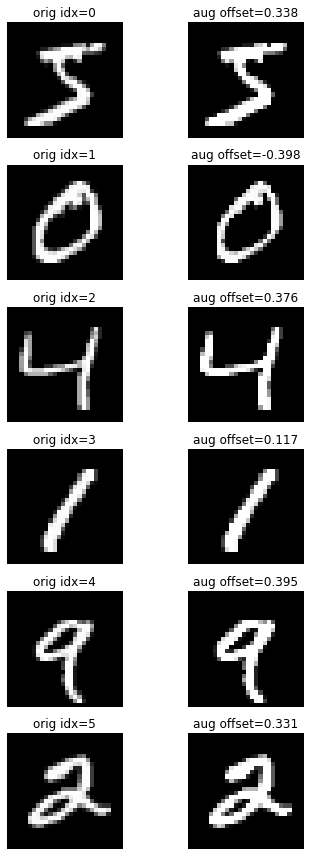

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def add_brightness_offset(x, low=-0.4, high=0.4, seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = x.astype(np.float32)
    x_off = x.copy()
    n = x_off.shape[0]

    if x_off.ndim == 4:            # (N, H, W, C)
        offsets = np.random.uniform(low, high, size=(n, 1, 1, 1)).astype(np.float32)
    elif x_off.ndim == 3:          # (N, H, W)
        offsets = np.random.uniform(low, high, size=(n, 1, 1)).astype(np.float32)

    x_off = x_off + offsets            
    np.clip(x_off, 0.0, 1.0, out=x_off)  

    offsets_1d = offsets.reshape(n)
    return x_off, offsets_1d

# Augmentation:
x_train_off, offsets = add_brightness_offset(x_train, low=-0.4, high=0.4)

# 6 examples, original vs augmented:
n_show = 6
fig, axes = plt.subplots(n_show, 2, figsize=(6, 2*n_show))
for i in range(n_show):
    orig = x_train[i].squeeze()
    aug  = x_train_off[i].squeeze()
    axes[i,0].imshow(orig, cmap='gray') 
    axes[i,0].set_title(f"orig idx={i}")
    axes[i,1].imshow(aug, cmap='gray')
    axes[i,1].set_title(f"aug offset={offsets[i]:.3f}")
    axes[i,0].axis('off'); axes[i,1].axis('off')
plt.tight_layout()
plt.show()


In [6]:
model_off = Sequential()
model_off.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model_off.add(Conv2D(64, (3, 3), activation='relu'))
model_off.add(MaxPooling2D(pool_size=(2, 2)))
model_off.add(Dropout(0.25))
model_off.add(Flatten())
model_off.add(Dense(128, activation='relu'))
model_off.add(Dropout(0.5))
model_off.add(Dense(10, activation='softmax'))

model_off.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_3 (Dense)              (None, 128)               1179776   
_________________________________________________________________
dropout_4 (Dropout)          (None, 128)              

In [7]:
model_off.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

model_off.fit(x_train_off, y_train,
          batch_size=128,
          epochs=12,
          verbose=1,
          validation_data=(x_test, y_test))

score_off = model_off.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 111s 2ms/step - loss: 0.2728 - accuracy: 0.9181 - val_loss: 0.0542 - val_accuracy: 0.9825
Epoch 2/12
60000/60000 [==============================] - 110s 2ms/step - loss: 0.0956 - accuracy: 0.9717 - val_loss: 0.0403 - val_accuracy: 0.9864
Epoch 3/12
60000/60000 [==============================] - 111s 2ms/step - loss: 0.0708 - accuracy: 0.9788 - val_loss: 0.0329 - val_accuracy: 0.9889
Epoch 4/12
60000/60000 [==============================] - 112s 2ms/step - loss: 0.0581 - accuracy: 0.9823 - val_loss: 0.0364 - val_accuracy: 0.9887
Epoch 5/12
60000/60000 [==============================] - 110s 2ms/step - loss: 0.0481 - accuracy: 0.9855 - val_loss: 0.0400 - val_accuracy: 0.9876
Epoch 6/12
60000/60000 [==============================] - 109s 2ms/step - loss: 0.0427 - accuracy: 0.9870 - val_loss: 0.0367 - val_accuracy: 0.9905
Epoch 7/12
60000/60000 [==============================] - 110s

In [8]:
score_off = model_off.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print('Test loss with offset:', score_off[0])
print('Test accuracy with offset:', score_off[1])

Test loss: 0.035298989139260516
Test accuracy: 0.9911999702453613
Test loss with offset: 0.035298989139260516
Test accuracy with offset: 0.9911999702453613


Observation: The random offset in the brightness for the images resulted in a higher loss and a lower accuracy (so a worse performance), compared to the original model. At first this seems counterintuitive, since data augmentation should prevent overfitting, and thus result in a higher test accuracy. However, it actually makes sense, since the original data was not used in the second model. Augmented data should be an addition to the original data, not a replacement. Combining the models into one bigger model would probably give the best results.

Implement data augmentation procedure that in addition to brightness augmentation also performs b-spline geometric augmentation using the [`gryds`](https://github.com/tueimage/gryds) package (you can look at the documentation of the package for an example on how to do that). Compare the new model with the baseline and the model that only performs brightness augmentation. implementation:

In [9]:
import gryds

def augment_image(image):
    offset = np.random.uniform(-0.2, 0.2)
    image_aug = np.clip(image + offset, 0, 1)

    image_2d = image_aug.squeeze()  #(28,28) 

    # Random displacements: (2, control_points_y, control_points_x)
    displacements = np.random.randn(2, 3, 3) * 0.3  
    transform = gryds.BSplineTransformation(displacements)

    interpolator = gryds.Interpolator(image_2d)
    warped = interpolator.transform(transform)

    return warped[..., np.newaxis]  # terug naar (28,28,1)

x_train_both = np.array([augment_image(img) for img in x_train])


In [10]:
model_both = Sequential()
model_both.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model_both.add(Conv2D(64, (3, 3), activation='relu'))
model_both.add(MaxPooling2D(pool_size=(2, 2)))
model_both.add(Dropout(0.25))
model_both.add(Flatten())
model_both.add(Dense(128, activation='relu'))
model_both.add(Dropout(0.5))
model_both.add(Dense(10, activation='softmax'))

model_both.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_5 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_5 (Dense)              (None, 128)               1179776   
_________________________________________________________________
dropout_6 (Dropout)          (None, 128)              

In [11]:
model_both.compile(loss=categorical_crossentropy, optimizer=Adam(), metrics=['accuracy'])

model_both.fit(x_train_off, y_train,
          batch_size=128,
          epochs=12,
          verbose=1,
          validation_data=(x_test, y_test))

score_both = model_both.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 110s 2ms/step - loss: 0.2786 - accuracy: 0.9160 - val_loss: 0.0614 - val_accuracy: 0.9815
Epoch 2/12
60000/60000 [==============================] - 109s 2ms/step - loss: 0.0977 - accuracy: 0.9717 - val_loss: 0.0385 - val_accuracy: 0.9868
Epoch 3/12
60000/60000 [==============================] - 109s 2ms/step - loss: 0.0719 - accuracy: 0.9785 - val_loss: 0.0374 - val_accuracy: 0.9878
Epoch 4/12
60000/60000 [==============================] - 108s 2ms/step - loss: 0.0576 - accuracy: 0.9830 - val_loss: 0.0328 - val_accuracy: 0.9897
Epoch 5/12
60000/60000 [==============================] - 110s 2ms/step - loss: 0.0513 - accuracy: 0.9846 - val_loss: 0.0329 - val_accuracy: 0.9901
Epoch 6/12
60000/60000 [==============================] - 107s 2ms/step - loss: 0.0426 - accuracy: 0.9866 - val_loss: 0.0350 - val_accuracy: 0.9902
Epoch 7/12
60000/60000 [==============================] - 108s

In [14]:
score_both = model_both.evaluate(x_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print('Test loss with offset:', score_off[0])
print('Test accuracy with offset:', score_off[1])
print('Test loss with offset and b-split:', score_both[0])
print('Test accuracy with offset and b-split:', score_both[1])

Test loss: 0.028865184726537745
Test accuracy: 0.9914000034332275
Test loss with offset: 0.035298989139260516
Test accuracy with offset: 0.9911999702453613
Test loss with offset and b-split: 0.029441841042595094
Test accuracy with offset and b-split: 0.9919000267982483


Observation: The model that was trained on the fully augmented data performed better than the model that was based on just the brightness augmentation. This shows that the extra b-spline augmentation step has a positive impact on the performance of the model.\
When comparing with the original model, the fully augmented model has a higher accuracy, but also a higher test loss. Again, the best results would probably be achieved when combining both models, or even combining all three. It should be noted that all individual models perform really well, so in practice it would in this case probably not be worth combining the models, considering the extra computational power and time that would be needed.